# 🎯 Actividad de Enganche — Capítulo 7: Cambios de Base

## ¿Por qué habría dos formas distintas de describir el mismo punto?

---

Antes de estudiar la teoría formal, exploremos intuitivamente por qué los **sistemas de referencia** importan.

Considera estas situaciones cotidianas:

- 📍 Tu posición en la ciudad puede darse en coordenadas GPS (latitud, longitud) **o** como distancia y dirección desde un punto de referencia local.
- 🗺️ Un punto en un mapa se puede describir desde el sistema de Buenos Aires o desde el de Nueva York — ¡el punto no cambia!
- ⬅️➡️ En ajedrez, una casilla puede identificarse como E4 (sistema estándar) o como "2 diagonales desde el alfil" (sistema relativo).

> 💡 **Pregunta de reflexión:** ¿Cambia el objeto cuando cambias el sistema de descripción?

## 🔍 Exploración 1: El punto $(3,2)$ en dos sistemas de referencia

Considera el punto $\mathbf{v} = (3, 2)$ en el plano.

En el sistema estándar, las coordenadas son simplemente $(3, 2)$.

Ahora imagina un sistema de referencia **rotado** 45°. ¿Cuáles son las coordenadas de ese mismo punto en el nuevo sistema?

¡Vamos a verlo visualmente!

**Antes de correr el código:**
> ✍️ *¿Crees que las coordenadas serán mayores o menores que $(3,2)$? ¿Por qué?*

<>:23: SyntaxWarning: invalid escape sequence '\ '
<>:23: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_8984/1703746819.py:23: SyntaxWarning: invalid escape sequence '\ '
  f'Coordenadas:\n$x=3,\ y=2$'),


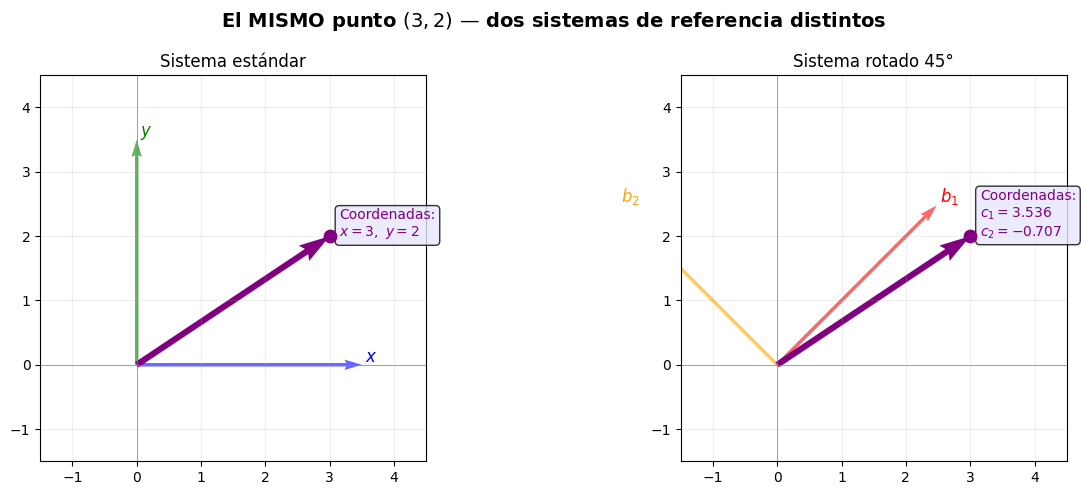

Coordenadas estándar: (3, 2)
Coordenadas en base rotada 45°: (3.5355, -0.7071)
¿Es el mismo punto? ¡Sí! — verificado: P @ v_B = [3. 2.]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# El punto en el plano
v = np.array([3., 2.])

# Base estándar
e1, e2 = np.array([1., 0.]), np.array([0., 1.])

# Base rotada 45°
theta = np.radians(45)
b1 = np.array([np.cos(theta), np.sin(theta)])
b2 = np.array([-np.sin(theta), np.cos(theta)])
P = np.column_stack([b1, b2])
v_B = np.linalg.solve(P, v)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('El MISMO punto $(3,2)$ — dos sistemas de referencia distintos', fontsize=14, fontweight='bold')

for ax, axes_vecs, labels, colors, coords_text in [
    (axes[0], [e1*3.5, e2*3.5], ['$x$', '$y$'], ['blue','green'],
     f'Coordenadas:\n$x=3,\ y=2$'),
    (axes[1], [b1*3.5, b2*3.5], ['$b_1$', '$b_2$'], ['red','orange'],
     f'Coordenadas:\n$c_1={v_B[0]:.3f}$\n$c_2={v_B[1]:.3f}$')
]:
    ax.set_xlim(-1.5, 4.5); ax.set_ylim(-1.5, 4.5)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    for vec, lbl, col in zip(axes_vecs, labels, colors):
        ax.quiver(0,0,vec[0],vec[1],angles='xy',scale_units='xy',scale=1,
                  color=col,width=0.009,alpha=0.6)
        ax.text(vec[0]+0.05, vec[1]+0.05, lbl, color=col, fontsize=12)
    ax.quiver(0,0,v[0],v[1],angles='xy',scale_units='xy',scale=1,
              color='purple',width=0.016, label='Punto v')
    ax.scatter(*v, color='purple', s=80, zorder=5)
    ax.text(v[0]+0.15,v[1],coords_text, fontsize=10, color='purple',
            bbox=dict(boxstyle='round',facecolor='lavender',alpha=0.8))

axes[0].set_title('Sistema estándar', fontsize=12)
axes[1].set_title('Sistema rotado 45°', fontsize=12)
plt.tight_layout()
plt.savefig('/tmp/enganche_vis.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Coordenadas estándar: (3, 2)")
print(f"Coordenadas en base rotada 45°: ({v_B[0]:.4f}, {v_B[1]:.4f})")
print(f"¿Es el mismo punto? {'¡Sí!' if np.allclose(P @ v_B, v) else 'No'} — verificado: P @ v_B = {np.round(P @ v_B, 4)}")

## 🧭 Exploración 2: Coordenadas polares vs. cartesianas

Otro ejemplo de cambio de sistema de referencia que ya conoces:
las **coordenadas polares** $(r, \theta)$ vs. las **coordenadas cartesianas** $(x, y)$.

El punto $(3, 4)$ en cartesianas es el mismo que... ¿cuál en polares?

$$r = \sqrt{x^2 + y^2} = \sqrt{9+16} = 5, \qquad \theta = \arctan(4/3) \approx 53.1°$$

> 🔑 Este es exactamente el espíritu del cambio de base: **el mismo objeto**, representado en
> sistemas distintos. La conversión $P$ (o $(r,\theta) \leftrightarrow (x,y)$) es el puente.

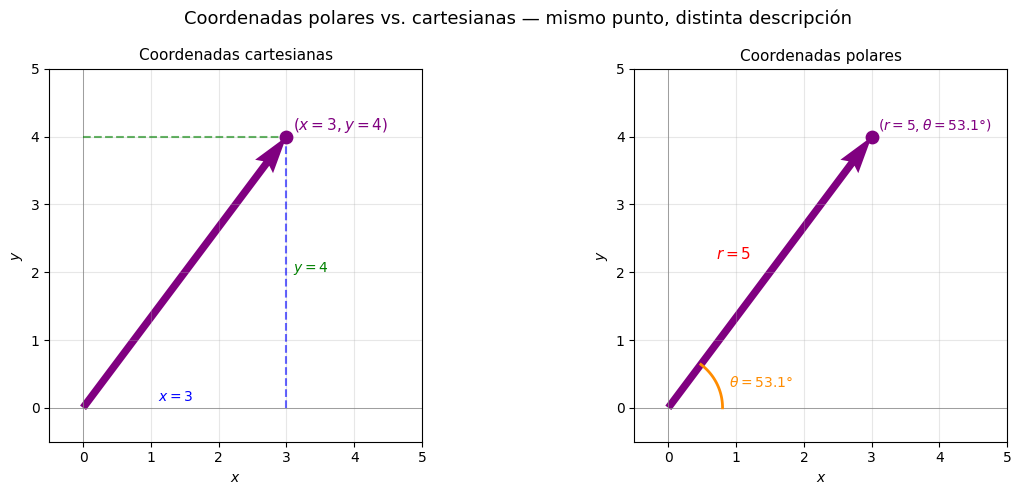

Mismo punto: cartesiano (3.0, 4.0) ↔ polar (r=5.00, θ=53.1°)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Coordenadas polares vs. cartesianas — mismo punto, distinta descripción', fontsize=13)

x, y = 3., 4.
r = np.sqrt(x**2 + y**2)
theta_rad = np.arctan2(y, x)
theta_deg = np.degrees(theta_rad)

# Cartesianas
ax = axes[0]
ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.quiver(0,0,x,y, angles='xy', scale_units='xy', scale=1, color='purple', width=0.02)
ax.plot([x,x],[0,y],'b--',alpha=0.6); ax.plot([0,x],[y,y],'g--',alpha=0.6)
ax.scatter(x,y,color='purple',s=80,zorder=5)
ax.text(x+0.1,y+0.1,f'$(x={x:.0f}, y={y:.0f})$',fontsize=11,color='purple')
ax.text(x/2-0.4,0.1,f'$x={x:.0f}$',color='blue',fontsize=10)
ax.text(x+0.1,y/2,f'$y={y:.0f}$',color='green',fontsize=10)
ax.set_title('Coordenadas cartesianas', fontsize=11)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')

# Polares
ax2 = axes[1]
ax2.set_xlim(-0.5, 5); ax2.set_ylim(-0.5, 5)
ax2.set_aspect('equal'); ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='gray', lw=0.5); ax2.axvline(0, color='gray', lw=0.5)
arc = np.linspace(0, theta_rad, 60)
ax2.plot(np.cos(arc)*0.8, np.sin(arc)*0.8, 'darkorange', lw=2)
ax2.text(0.9, 0.3, f'$\\theta={theta_deg:.1f}°$', color='darkorange', fontsize=10)
ax2.quiver(0,0,x,y, angles='xy', scale_units='xy', scale=1, color='purple', width=0.02)
ax2.scatter(x,y,color='purple',s=80,zorder=5)
ax2.text(x/2-0.8,y/2+0.2,f'$r={r:.0f}$',color='red',fontsize=11)
ax2.text(x+0.1,y+0.1,f'$(r={r:.0f}, \\theta={theta_deg:.1f}°)$',fontsize=10,color='purple')
ax2.set_title('Coordenadas polares', fontsize=11)
ax2.set_xlabel('$x$'); ax2.set_ylabel('$y$')

plt.tight_layout(); plt.show()
print(f"Mismo punto: cartesiano ({x}, {y}) ↔ polar (r={r:.2f}, θ={theta_deg:.1f}°)")

## 🧩 Exploración 3: Encuentra las coordenadas

Dada la base $\mathcal{B} = \{\mathbf{b}_1, \mathbf{b}_2\}$ con $\mathbf{b}_1 = (2, 0)$ y $\mathbf{b}_2 = (1, 1)$,
¿cuáles son las coordenadas de los siguientes vectores en la base $\mathcal{B}$?

| Vector estándar | Coordenadas en $\mathcal{B}$ |
|:---:|:---:|
| $(2, 0)$ | ? |
| $(1, 1)$ | ? |
| $(4, 2)$ | ? |
| $(3, 1)$ | ? |

> ✍️ **Intenta resolverlo a mano primero.** Luego ejecuta el código para verificar.

In [3]:
import numpy as np

# Base B = {b1, b2}
b1 = np.array([2., 0.])
b2 = np.array([1., 1.])
P = np.column_stack([b1, b2])
P_inv = np.linalg.inv(P)

# Vectores a convertir
vectores = {
    '(2, 0)': np.array([2., 0.]),
    '(1, 1)': np.array([1., 1.]),
    '(4, 2)': np.array([4., 2.]),
    '(3, 1)': np.array([3., 1.])
}

print(f"Base B: b1 = {b1}, b2 = {b2}")
print(f"Matriz P:\n{P}")
print("\n" + "─"*50)
print(f"{'Vector estándar':<20} {'Coordenadas en B':<25} {'Verificación'}")
print("─"*60)

for nombre, v in vectores.items():
    v_B = P_inv @ v
    check = np.allclose(P @ v_B, v)
    print(f"{nombre:<20} c1={v_B[0]:.3f}, c2={v_B[1]:.3f}   {'✓' if check else '✗'}")

print("\n💡 Observa:")
print("   (2,0) = 1·b1 + 0·b2  → coordenadas (1, 0) — b1 mismo")
print("   (1,1) = 0·b1 + 1·b2  → coordenadas (0, 1) — b2 mismo")

Base B: b1 = [2. 0.], b2 = [1. 1.]
Matriz P:
[[2. 1.]
 [0. 1.]]

──────────────────────────────────────────────────
Vector estándar      Coordenadas en B          Verificación
────────────────────────────────────────────────────────────
(2, 0)               c1=1.000, c2=0.000   ✓
(1, 1)               c1=0.000, c2=1.000   ✓
(4, 2)               c1=1.000, c2=2.000   ✓
(3, 1)               c1=1.000, c2=1.000   ✓

💡 Observa:
   (2,0) = 1·b1 + 0·b2  → coordenadas (1, 0) — b1 mismo
   (1,1) = 0·b1 + 1·b2  → coordenadas (0, 1) — b2 mismo


## 🤔 Preguntas de Reflexión

Antes de pasar a la teoría formal, responde estas preguntas:

1. **¿Qué cambia y qué no cambia** cuando pasas a un nuevo sistema de referencia?

2. ¿Por qué crees que los vectores de la nueva base expresados en coordenadas estándar
   son exactamente lo que necesitas para construir la *"tabla de traducción"* entre bases?

3. ¿Cuándo podría ser **conveniente** cambiar de base? ¿Qué tipos de problemas se simplificarían?

4. ¿Existe una base en la que cualquier vector sea *fácil* de expresar? (Pista: piensa en la base estándar.)

5. Si tengo un vector con coordenadas $(1, 0)$ en la base $\mathcal{B}$, ¿cuáles son sus
   coordenadas estándar? ¿Qué relación tiene esto con las columnas de $P$?

---

> 📘 **Conecta con lo que sabes:** ¿Usaste alguna vez coordenadas polares? ¿O el sistema de
> referencia de un barco (proa/estribor)? Todos son cambios de base.

---

### 🚀 ¡Estás listo para la teoría!

Ahora que tienes la intuición geométrica, estudia `concepto.ipynb` para ver el
**álgebra detrás** de estos cambios de perspectiva.

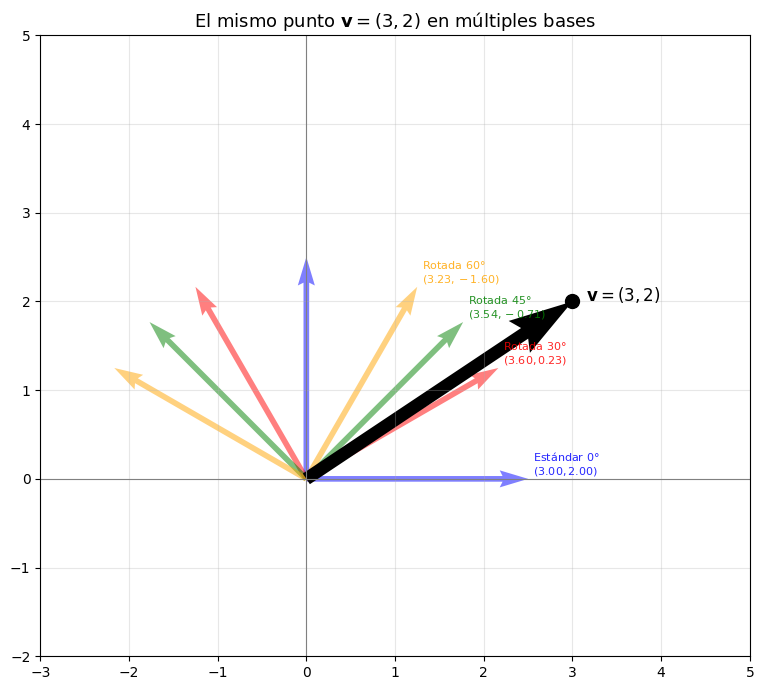

El punto negro es siempre el mismo. Las coordenadas cambian según la base.


In [4]:
# Resumen visual: la misma idea con múltiples bases
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 7))
ax.set_xlim(-3, 5); ax.set_ylim(-2, 5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', lw=0.8); ax.axvline(0, color='gray', lw=0.8)
ax.set_title('El mismo punto $\\mathbf{v}=(3,2)$ en múltiples bases', fontsize=13)

v = np.array([3., 2.])

bases = [
    (0,   'Estándar $0°$',   'blue'),
    (30,  'Rotada $30°$',    'red'),
    (45,  'Rotada $45°$',    'green'),
    (60,  'Rotada $60°$',    'orange'),
]

for theta_deg, label, color in bases:
    theta = np.radians(theta_deg)
    b1 = np.array([np.cos(theta), np.sin(theta)])
    b2 = np.array([-np.sin(theta), np.cos(theta)])
    P = np.column_stack([b1, b2])
    v_B = np.linalg.solve(P, v)
    scale = 2.5
    ax.quiver(0,0,b1[0]*scale,b1[1]*scale,angles='xy',scale_units='xy',scale=1,
              color=color,width=0.008,alpha=0.5)
    ax.quiver(0,0,b2[0]*scale,b2[1]*scale,angles='xy',scale_units='xy',scale=1,
              color=color,width=0.008,alpha=0.5,linestyle=':')
    ax.text(b1[0]*scale+0.05,b1[1]*scale+0.05,
            f'{label}\n$({v_B[0]:.2f},{v_B[1]:.2f})$',
            color=color,fontsize=8,alpha=0.85)

ax.quiver(0,0,v[0],v[1],angles='xy',scale_units='xy',scale=1,
          color='black',width=0.018)
ax.scatter(*v, color='black', s=100, zorder=10)
ax.text(v[0]+0.15, v[1], '$\\mathbf{v}=(3,2)$', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print("El punto negro es siempre el mismo. Las coordenadas cambian según la base.")

## 📘 Conectando con el Capítulo

Esta actividad te preparó para entender:

| Intuición (esta actividad) | Concepto formal (teoria/) |
|:---|:---|
| "Tabla de traducción" entre bases | Matriz de cambio de base $P$ |
| Coordenadas del punto en nuevo sistema | Vector $[\mathbf{v}]_\mathcal{B} = P^{-1}\mathbf{v}$ |
| Recuperar punto original | $\mathbf{v} = P[\mathbf{v}]_\mathcal{B}$ |
| Distintas bases, mismo objeto | Matrices similares $A \sim A_\mathcal{B}$ |

> 🎯 **Próximo paso:** Abre `teoria/concepto.ipynb` para ver la teoría completa.